# H5 — Diferenças Regionais na Gravidade dos Sinistros

**Hipótese:** O perfil de gravidade dos sinistros difere entre as cinco regiões brasileiras, com regiões de maior extensão de pista simples apresentando taxas de fatalidade superiores às de maior infraestrutura duplicada.

**Testes aplicados:**
- Qui-quadrado de independência `regiao` × `is_fatal` + V de Cramér (tamanho de efeito)
- Crosstab de taxas de fatalidade por `tipo_pista` (Simples / Dupla / Múltipla)
- Post-hoc pairwise: z-test de duas proporções com correção de Bonferroni (k=10 pares)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

from prf_sdk.analysis.hypotheses.h5 import verify_h5, FATAL_CLASSES, PISTA_SIMPLES

In [2]:
BASE_DIR = Path(__name__).resolve().parent.parent

## 1. Carregamento e verificação

In [3]:
df = pd.read_csv(
    BASE_DIR / "data/processed/datatran_2022_2026_processed_v1.csv",
    index_col=0,
    low_memory=False,
)
pd.set_option("display.max_columns", None)
df.head()

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive,n_caracteristicas_tracado,causa_acidente_grupo,feriado_nacional,estacao,regiao,mes,horario,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,1,0,0,0,0,0,0,0,1,infracao_comportamento_risco,1,Verão,Sul,1,Madrugada,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,1,0,0,0,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Centro-Oeste,1,Madrugada,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,1,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Sudeste,1,Manhã,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_ambiental,1,Verão,Sudeste,1,Manhã,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_saude_condutor,1,Verão,Nordeste,1,Manhã,5.0,1


In [4]:
print("Regiões disponíveis:")
print(df["regiao"].value_counts())
print()
print("Tipos de pista:")
print(df["tipo_pista"].value_counts())

Regiões disponíveis:
regiao
Sudeste         94491
Sul             88243
Nordeste        65480
Centro-Oeste    35697
Norte           16175
Name: count, dtype: int64

Tipos de pista:
tipo_pista
Simples     145829
Dupla       125895
Múltipla     28362
Name: count, dtype: int64


In [5]:
result = verify_h5(df)
print(result.summary)

H5 — Diferenças regionais na gravidade dos sinistros
  χ²(regiao × fatal) = 2023.65  p = 0.00e+00  V de Cramér = 0.0820

  Taxa de fatalidade por tipo de pista:
    Simples   : 9.88%  (n=145,829)
    Dupla     : 4.71%  (n=125,895)
    Múltipla  : 4.19%  (n=28,362)

  Taxa de fatalidade e proporção de pista simples por região:
    Norte        : fatal=11.02%  pista_simples=69.9%
    Nordeste     : fatal=10.33%  pista_simples=55.5%
    Centro-Oeste : fatal=7.62%  pista_simples=51.9%
    Sudeste      : fatal=5.74%  pista_simples=40.4%
    Sul          : fatal=5.48%  pista_simples=46.9%

  Pares não significativos: Nordeste–Norte (p_adj=0.111); Sudeste–Sul (p_adj=0.182)
  Pares significativos (Bonferroni k=10): 8/10

  H5 confirmada.


## 2. Chi-quadrado — associação regional × fatalidade

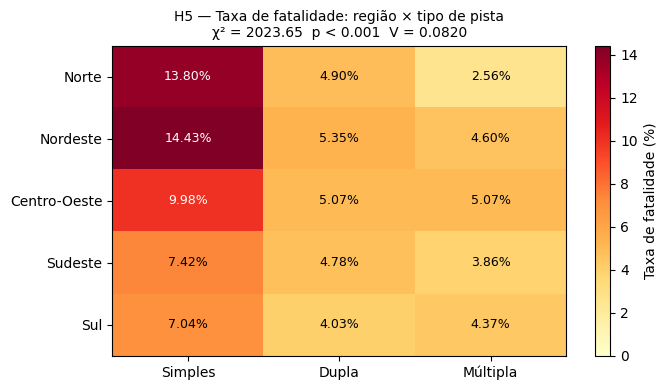

In [6]:
# Heatmap: taxa de fatalidade por região × tipo de pista
df_temp = df.assign(
    is_fatal=df["classificacao_acidente"].isin(FATAL_CLASSES) | (df["mortos"].fillna(0) > 0)
)

pivot = (
    df_temp.groupby(["regiao", "tipo_pista"])["is_fatal"]
    .mean()
    .unstack("tipo_pista")
    .reindex(columns=["Simples", "Dupla", "Múltipla"])
)

# Ordenar regiões por taxa global
region_order = (
    df_temp.groupby("regiao")["is_fatal"].mean().sort_values(ascending=False).index
)
pivot = pivot.loc[region_order]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values * 100, aspect="auto", cmap="YlOrRd", vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = "white" if val > 0.08 else "black"
            ax.text(j, i, f"{val*100:.2f}%", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, label="Taxa de fatalidade (%)")
ax.set_title(
    f"H5 — Taxa de fatalidade: região × tipo de pista\n"
    f"χ² = {result.chi2:.2f}  p < 0.001  V = {result.cramers_v:.4f}",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## 3. Taxas de fatalidade por tipo de pista

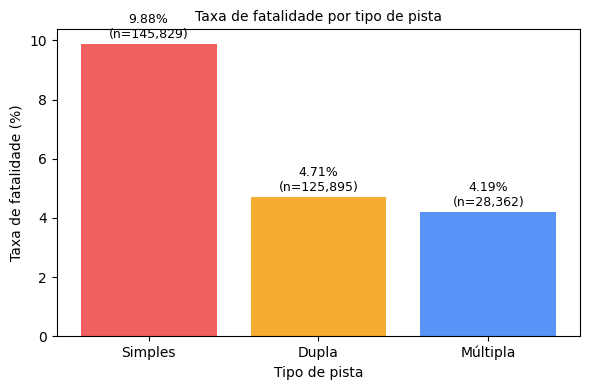

In [7]:
pista_df = pd.DataFrame(
    [
        {
            "tipo_pista": p.tipo_pista,
            "taxa_fatalidade": p.taxa_fatalidade,
            "n": p.total,
        }
        for p in result.pista_stats
    ]
)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#ef4444", "#f59e0b", "#3b82f6"]
bars = ax.bar(pista_df["tipo_pista"], pista_df["taxa_fatalidade"], color=colors, alpha=0.85)

for bar, row in zip(bars, pista_df.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{row.taxa_fatalidade:.2f}%\n(n={row.n:,})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_ylabel("Taxa de fatalidade (%)")
ax.set_xlabel("Tipo de pista")
ax.set_title("Taxa de fatalidade por tipo de pista", fontsize=10)
fig.tight_layout()
plt.show()

## 4. Relação entre infraestrutura regional e fatalidade

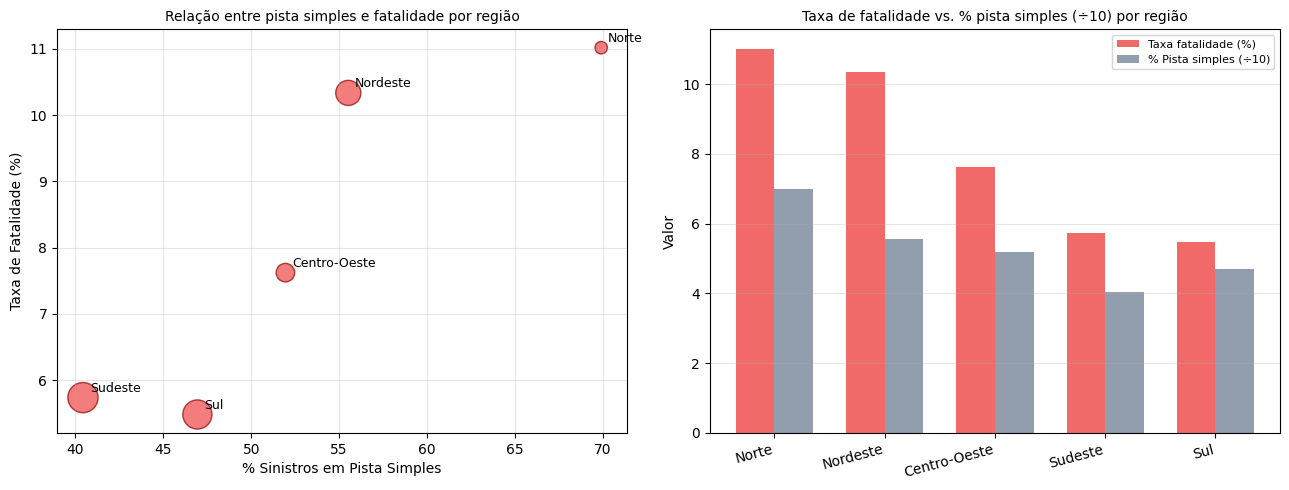

,taxa_fatalidade,pct_pista_simples,total
regiao,,,
Norte,11.02%,69.9%,"16,175"
Nordeste,10.33%,55.5%,"65,480"
Centro-Oeste,7.62%,51.9%,"35,697"
Sudeste,5.74%,40.4%,"94,491"
Sul,5.48%,46.9%,"88,243"


In [8]:
region_df = pd.DataFrame(
    [
        {
            "regiao": r.regiao,
            "taxa_fatalidade": r.taxa_fatalidade,
            "pct_pista_simples": r.pct_pista_simples,
            "total": r.total,
        }
        for r in result.region_stats
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: % pista simples vs taxa fatalidade
ax = axes[0]
scatter = ax.scatter(
    region_df["pct_pista_simples"],
    region_df["taxa_fatalidade"],
    s=region_df["total"] / 200,
    color="#ef4444",
    alpha=0.7,
    edgecolors="darkred",
)
for _, row in region_df.iterrows():
    ax.annotate(
        row["regiao"],
        (row["pct_pista_simples"], row["taxa_fatalidade"]),
        fontsize=9, xytext=(5, 4), textcoords="offset points",
    )
ax.set_xlabel("% Sinistros em Pista Simples")
ax.set_ylabel("Taxa de Fatalidade (%)")
ax.set_title("Relação entre pista simples e fatalidade por região", fontsize=10)
ax.grid(True, alpha=0.3)

# Barras duplas: taxa fatal + % pista simples
ax2 = axes[1]
x = np.arange(len(region_df))
width = 0.35
region_order_idx = region_df.sort_values("taxa_fatalidade", ascending=False).index
region_df_sorted = region_df.loc[region_order_idx].reset_index(drop=True)

b1 = ax2.bar(x - width / 2, region_df_sorted["taxa_fatalidade"], width, label="Taxa fatalidade (%)", color="#ef4444", alpha=0.8)
b2 = ax2.bar(x + width / 2, region_df_sorted["pct_pista_simples"] / 10, width, label="% Pista simples (÷10)", color="#64748b", alpha=0.7)

ax2.set_xticks(x)
ax2.set_xticklabels(region_df_sorted["regiao"], rotation=15, ha="right")
ax2.set_ylabel("Valor")
ax2.legend(fontsize=8)
ax2.set_title("Taxa de fatalidade vs. % pista simples (÷10) por região", fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

display(region_df.set_index("regiao").style.format({
    "taxa_fatalidade": "{:.2f}%",
    "pct_pista_simples": "{:.1f}%",
    "total": "{:,}",
}))

## 5. Post-hoc pairwise — Bonferroni (k=10)

In [9]:
posthoc_df = pd.DataFrame(
    [
        {
            "Par": f"{r.regiao_a} vs {r.regiao_b}",
            "taxa_a": r.taxa_a,
            "taxa_b": r.taxa_b,
            "z": r.z_statistic,
            "p_value": r.p_value,
            "p_value_bonferroni": r.p_value_bonferroni,
            "significativo": r.significant,
        }
        for r in result.posthoc
    ]
).set_index("Par")

display(
    posthoc_df.style
    .format({
        "taxa_a": "{:.2f}%",
        "taxa_b": "{:.2f}%",
        "z": "{:.3f}",
        "p_value": "{:.4f}",
        "p_value_bonferroni": "{:.4f}",
    })
    .apply(
        lambda col: [
            "background-color: #fca5a5" if v else ""
            for v in posthoc_df["significativo"]
        ],
        axis=0,
    )
)

,taxa_a,taxa_b,z,p_value,p_value_bonferroni,significativo
Par,,,,,,
Nordeste vs Sul,10.33%,5.48%,35.606,0.0000,0.0000,True
Nordeste vs Sudeste,10.33%,5.74%,34.080,0.0000,0.0000,True
Norte vs Sul,11.02%,5.48%,26.554,0.0000,0.0000,True
Norte vs Sudeste,11.02%,5.74%,25.154,0.0000,0.0000,True
Centro-Oeste vs Sul,7.62%,5.48%,14.255,0.0000,0.0000,True
Centro-Oeste vs Nordeste,7.62%,10.33%,-14.140,0.0000,0.0000,True
Centro-Oeste vs Norte,7.62%,11.02%,-12.720,0.0000,0.0000,True
Centro-Oeste vs Sudeste,7.62%,5.74%,12.534,0.0000,0.0000,True
Nordeste vs Norte,10.33%,11.02%,-2.539,0.0111,0.1112,False


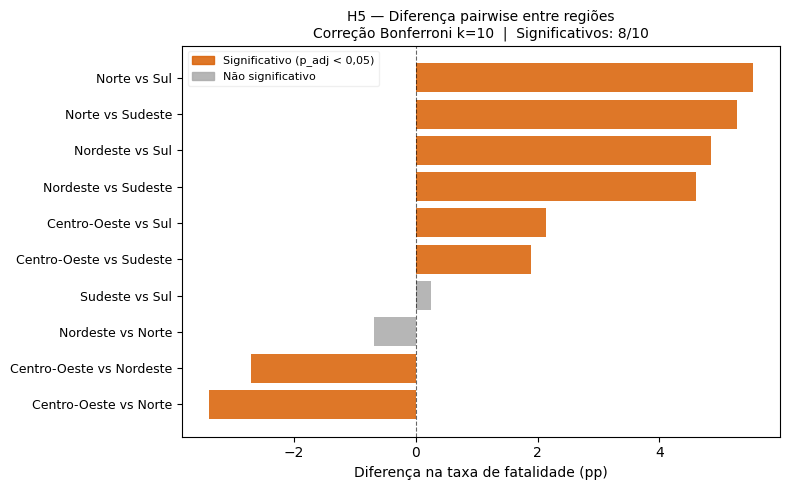

In [10]:
# Forest plot das diferenças de taxa entre pares
ph = sorted(result.posthoc, key=lambda x: x.taxa_a - x.taxa_b)
labels = [f"{r.regiao_a} vs {r.regiao_b}" for r in ph]
diffs = [r.taxa_a - r.taxa_b for r in ph]
colors_ph = ["#d95f02" if r.significant else "#aaaaaa" for r in ph]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(ph))
ax.barh(y_pos, diffs, color=colors_ph, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Diferença na taxa de fatalidade (pp)")
ax.set_title(
    f"H5 — Diferença pairwise entre regiões\n"
    f"Correção Bonferroni k=10  |  Significativos: {sum(r.significant for r in ph)}/10",
    fontsize=10,
)
sig_patch = mpatches.Patch(color="#d95f02", alpha=0.85, label="Significativo (p_adj < 0,05)")
ns_patch = mpatches.Patch(color="#aaaaaa", alpha=0.85, label="Não significativo")
ax.legend(handles=[sig_patch, ns_patch], framealpha=0.3, fontsize=8)
fig.tight_layout()
plt.show()

## 6. Resultado final

In [11]:
print("=" * 60)
print(result.summary)
print("=" * 60)
print(f"\nH5 confirmada: {result.confirmed}")
print(f"  χ² = {result.chi2:.2f}  p < 0.001  V de Cramér = {result.cramers_v:.4f}")
print()
print("Detalhamento por região:")
display(
    pd.DataFrame(
        [
            {
                "regiao": r.regiao,
                "total": r.total,
                "fatais": r.fatais,
                "taxa_fatalidade": r.taxa_fatalidade,
                "pct_pista_simples": r.pct_pista_simples,
            }
            for r in result.region_stats
        ]
    )
    .set_index("regiao")
    .style.format({
        "total": "{:,}",
        "fatais": "{:,}",
        "taxa_fatalidade": "{:.2f}%",
        "pct_pista_simples": "{:.1f}%",
    })
)

H5 — Diferenças regionais na gravidade dos sinistros
  χ²(regiao × fatal) = 2023.65  p = 0.00e+00  V de Cramér = 0.0820

  Taxa de fatalidade por tipo de pista:
    Simples   : 9.88%  (n=145,829)
    Dupla     : 4.71%  (n=125,895)
    Múltipla  : 4.19%  (n=28,362)

  Taxa de fatalidade e proporção de pista simples por região:
    Norte        : fatal=11.02%  pista_simples=69.9%
    Nordeste     : fatal=10.33%  pista_simples=55.5%
    Centro-Oeste : fatal=7.62%  pista_simples=51.9%
    Sudeste      : fatal=5.74%  pista_simples=40.4%
    Sul          : fatal=5.48%  pista_simples=46.9%

  Pares não significativos: Nordeste–Norte (p_adj=0.111); Sudeste–Sul (p_adj=0.182)
  Pares significativos (Bonferroni k=10): 8/10

  H5 confirmada.

H5 confirmada: True
  χ² = 2023.65  p < 0.001  V de Cramér = 0.0820

Detalhamento por região:


,total,fatais,taxa_fatalidade,pct_pista_simples
regiao,,,,
Norte,"16,175","1,782",11.02%,69.9%
Nordeste,"65,480","6,767",10.33%,55.5%
Centro-Oeste,"35,697","2,721",7.62%,51.9%
Sudeste,"94,491","5,421",5.74%,40.4%
Sul,"88,243","4,838",5.48%,46.9%
